<a href="https://colab.research.google.com/github/mf2056/F20AA_CW2/blob/main/Step2%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Text Processing and Normalization**

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn nltk scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

import re

nltk.download('punkt')      # for tokenization
nltk.download('punkt_tab')
nltk.download('stopwords')  # for removing common words
nltk.download('wordnet')    # for lemmatization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
train = pd.read_csv("train.csv")
train.head()

,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1
3,"To find it, either park in front of the Tuesda...",4
4,Mall location. Used their services for sedan. ...,4


In [4]:
train.shape

(288000, 2)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    288000 non-null  object
 1   rating  288000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.4+ MB


In [6]:
def basic_clean(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['text'] = train['text'].apply(basic_clean)
train.head()

,text,rating
0,this place is terrible the people in charge ar...,2
1,terrible service and they are saying that i ne...,1
2,absolutely terrible company they sent me to co...,1
3,to find it either park in front of the tuesday...,4
4,mall location used their services for sedan ni...,4


In [7]:
train["tokens"] = train["text"].apply(word_tokenize)
train.head()

,text,rating,tokens
0,this place is terrible the people in charge ar...,2,"[this, place, is, terrible, the, people, in, c..."
1,terrible service and they are saying that i ne...,1,"[terrible, service, and, they, are, saying, th..."
2,absolutely terrible company they sent me to co...,1,"[absolutely, terrible, company, they, sent, me..."
3,to find it either park in front of the tuesday...,4,"[to, find, it, either, park, in, front, of, th..."
4,mall location used their services for sedan ni...,4,"[mall, location, used, their, services, for, s..."


In [8]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

train["tokens"] = train["tokens"].apply(remove_stopwords)
train.head()

,text,rating,tokens
0,this place is terrible the people in charge ar...,2,"[place, terrible, people, charge, worst, part,..."
1,terrible service and they are saying that i ne...,1,"[terrible, service, saying, never, used, servi..."
2,absolutely terrible company they sent me to co...,1,"[absolutely, terrible, company, sent, collecti..."
3,to find it either park in front of the tuesday...,4,"[find, either, park, front, tuesday, morning, ..."
4,mall location used their services for sedan ni...,4,"[mall, location, used, services, sedan, nice, ..."


In [9]:
stemmer = PorterStemmer()

def stem_words(tokens):
    return [stemmer.stem(w) for w in tokens]

train["stemmed"] = train["tokens"].apply(stem_words)

In [10]:
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(w) for w in tokens]

train["lemmatized"] = train["tokens"].apply(lemmatize_words)

In [11]:
train["text_stem"] = train["stemmed"].apply(lambda x: " ".join(x))
train["text_lemma"] = train["lemmatized"].apply(lambda x: " ".join(x))

train[["text","text_stem","text_lemma"]].head(10)

,text,text_stem,text_lemma
0,this place is terrible the people in charge ar...,place terribl peopl charg worst part far yeah ...,place terrible people charge worst part far ye...
1,terrible service and they are saying that i ne...,terribl servic say never use servic lie call n...,terrible service saying never used service lie...
2,absolutely terrible company they sent me to co...,absolut terribl compani sent collect without a...,absolutely terrible company sent collection wi...
3,to find it either park in front of the tuesday...,find either park front tuesday morn mall entra...,find either park front tuesday morning mall en...
4,mall location used their services for sedan ni...,mall locat use servic sedan nice perhap inform...,mall location used service sedan nice perhaps ...
5,ebenezer reformed church is very haughty and t...,ebenez reform church haughti kick attend enoug...,ebenezer reformed church haughty kick attend e...
6,they have relocated wnorth ave oakpark il,reloc wnorth ave oakpark il,relocated wnorth ave oakpark il
7,it was great they really take their time very ...,great realli take time friendli,great really take time friendly
8,ordered the ramen on a cold jan nightwould giv...,order ramen cold jan nightwould give star abl ...,ordered ramen cold jan nightwould give star ab...
9,friendly service and always great food this on...,friendli servic alway great food one goto quic...,friendly service always great food one goto qu...


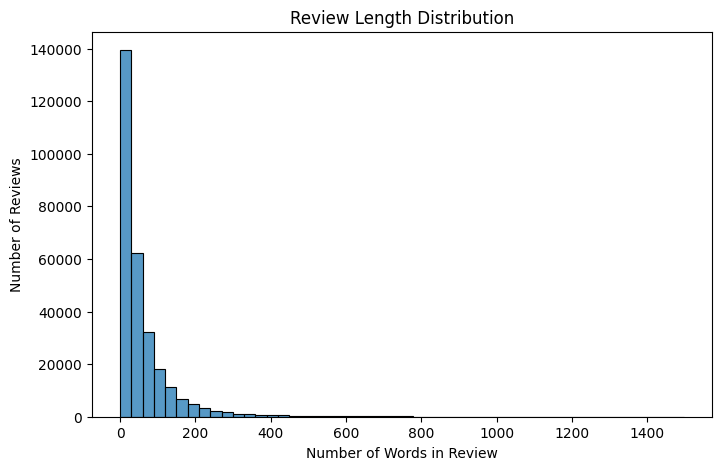

In [12]:
train["review_length"] = train["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(train["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words in Review")
plt.ylabel("Number of Reviews")

plt.show()

In [13]:
from collections import Counter

all_words = " ".join(train["text_lemma"]).split()
word_freq = Counter(all_words)
common_words = pd.DataFrame(word_freq.most_common(20), columns=["Word","Frequency"])

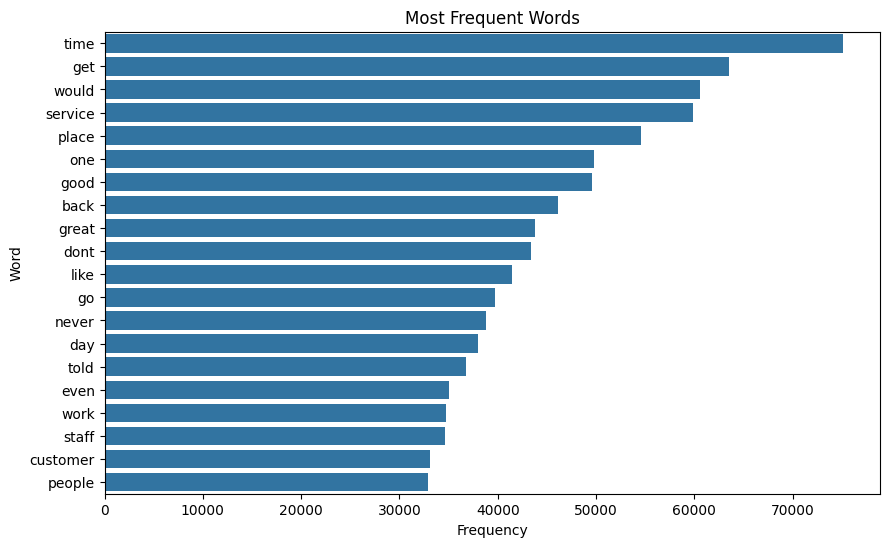

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x="Frequency", y="Word", data=common_words)
plt.title("Most Frequent Words")
plt.show()

## **Vector space Model and feature representation**

In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [16]:
X = train["text_lemma"]
y = train["rating"]

In [17]:
binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(X)

print(X_binary.shape)

(288000, 138760)


In [18]:
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(X)

print(X_count.shape)

(288000, 138760)


In [19]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X)

print(X_tfidf.shape)

(288000, 138760)


In [20]:
tfidf_uni = TfidfVectorizer(ngram_range=(1,1))
X_uni = tfidf_uni.fit_transform(X)

In [21]:
tfidf_bi = TfidfVectorizer(ngram_range=(1,2))
X_bi = tfidf_bi.fit_transform(X)

In [22]:
tfidf_tri = TfidfVectorizer(ngram_range=(1,3))
X_tri = tfidf_tri.fit_transform(X)

In [23]:
features = pd.DataFrame({
"Representation":["Binary","Count","TF-IDF","Unigram","Bigram","Trigram"],
"Features":[
X_binary.shape[1],
X_count.shape[1],
X_tfidf.shape[1],
X_uni.shape[1],
X_bi.shape[1],
X_tri.shape[1]
]
})

features

,Representation,Features
0,Binary,138760
1,Count,138760
2,TF-IDF,138760
3,Unigram,138760
4,Bigram,3027444
5,Trigram,9699147


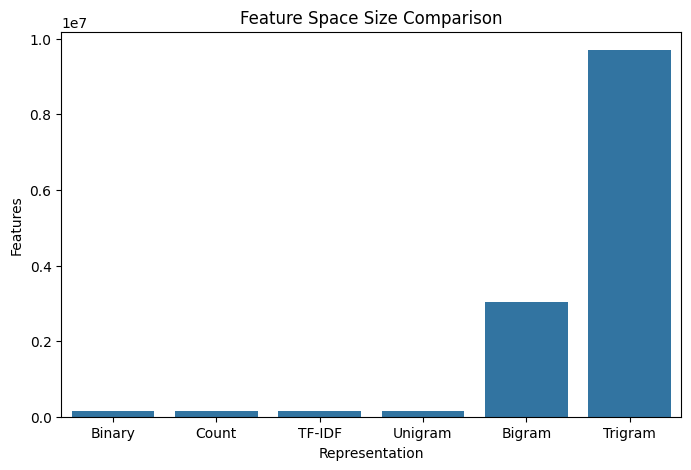

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x="Representation", y="Features", data=features)
plt.title("Feature Space Size Comparison")
plt.show()

In [25]:
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_df = pd.DataFrame({"word":feature_names,"score":tfidf_scores})
top_words = tfidf_df.sort_values("score", ascending=False).head(20)

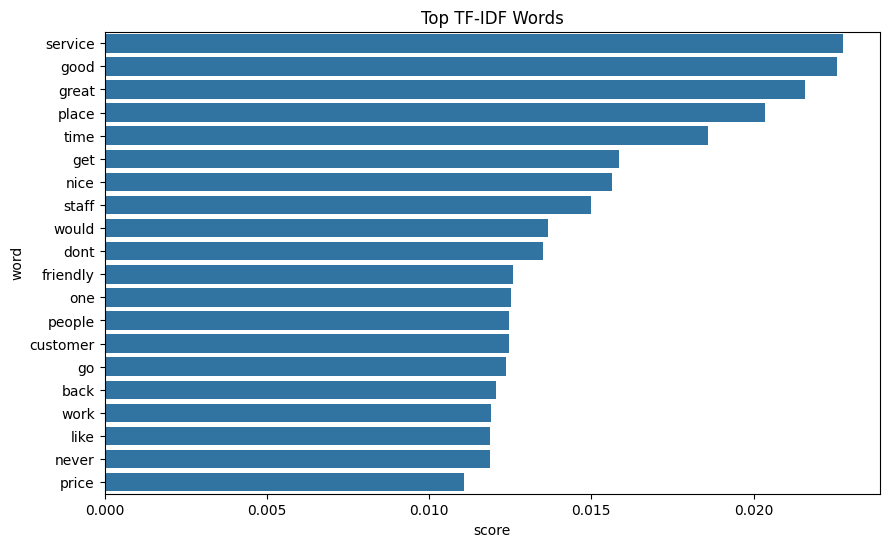

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x="score", y="word", data=top_words)
plt.title("Top TF-IDF Words")
plt.show()

In [27]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 12.1 MB/s eta 0:00:00


In [28]:
from gensim.models import Word2Vec

tokenized = train["tokens"]
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=2)
model.wv.most_similar("good")

[('great', 0.8271565437316895),
 ('decent', 0.7925671339035034),
 ('bad', 0.6651549339294434),
 ('okay', 0.6098060011863708),
 ('alright', 0.5882896780967712),
 ('excellent', 0.5879763960838318),
 ('awesome', 0.5775116682052612),
 ('ok', 0.5759363174438477),
 ('nice', 0.5754876732826233),
 ('fair', 0.5645797848701477)]

In [30]:
train.to_csv("train_processed.csv", index=False)

In [31]:
train.head()

,text,rating,tokens,stemmed,lemmatized,text_stem,text_lemma,review_length
0,this place is terrible the people in charge ar...,2,"[place, terrible, people, charge, worst, part,...","[place, terribl, peopl, charg, worst, part, fa...","[place, terrible, people, charge, worst, part,...",place terribl peopl charg worst part far yeah ...,place terrible people charge worst part far ye...,97
1,terrible service and they are saying that i ne...,1,"[terrible, service, saying, never, used, servi...","[terribl, servic, say, never, use, servic, lie...","[terrible, service, saying, never, used, servi...",terribl servic say never use servic lie call n...,terrible service saying never used service lie...,48
2,absolutely terrible company they sent me to co...,1,"[absolutely, terrible, company, sent, collecti...","[absolut, terribl, compani, sent, collect, wit...","[absolutely, terrible, company, sent, collecti...",absolut terribl compani sent collect without a...,absolutely terrible company sent collection wi...,211
3,to find it either park in front of the tuesday...,4,"[find, either, park, front, tuesday, morning, ...","[find, either, park, front, tuesday, morn, mal...","[find, either, park, front, tuesday, morning, ...",find either park front tuesday morn mall entra...,find either park front tuesday morning mall en...,66
4,mall location used their services for sedan ni...,4,"[mall, location, used, services, sedan, nice, ...","[mall, locat, use, servic, sedan, nice, perhap...","[mall, location, used, service, sedan, nice, p...",mall locat use servic sedan nice perhap inform...,mall location used service sedan nice perhaps ...,28
